In [1]:
# !pip install --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

In [2]:
# !pip install scikit-learn


In [3]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms.functional import to_tensor
import matplotlib.pyplot as plt
from tqdm import tqdm
from networks.vision_transformer import SwinUnet



c:\Users\tasni\miniconda3\envs\torch-env\lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [4]:
from PIL import Image

In [5]:
# !pip install tqdm

In [6]:
# pip install ipywidgets

In [7]:
# pip install --upgrade jupyterlab notebook

In [8]:
# jupyter nbextension enable --py widgetsnbextension --sys-prefix

In [9]:
# conda install -c conda-forge tqdm

In [10]:
from tqdm.notebook import tqdm
import time

for i in tqdm(range(100)):
    time.sleep(0.01)


  0%|          | 0/100 [00:00<?, ?it/s]

In [11]:
class Config:
    root_path = "./Dataset"  # <-- This must exist!
    img_size = 224
    num_classes = 3
    base_lr = 0.01
    batch_size = 4
    max_epochs = 100
    n_gpu = 1
    num_workers = 4
    eval_interval = 5
    seed = 42
    snapshot_path = "./swin_output"
    pretrained_ckpt = "./pretrained_ckpt/swin_tiny_patch4_window7_224.pth"

args = Config()


# Create output directory if it doesn't exist
os.makedirs(args.snapshot_path, exist_ok=True)

# Set random seed for reproducibility
torch.manual_seed(args.seed)


In [12]:
# #create HepaticDataset
# from PIL import Image   

# class HepaticDataset(Dataset):
#     def __init__(self, image_dir, mask_dir, transform=None):
#         self.image_dir = image_dir
#         self.mask_dir = mask_dir
#         self.transform = transform
#         self.image_files = sorted(os.listdir(image_dir))

#     def __len__(self):
#         return len(self.image_files)

#     def __getitem__(self, idx):
#         img_path = os.path.join(self.image_dir, self.image_files[idx])
#         mask_path = os.path.join(self.mask_dir, self.image_files[idx])

#         image = Image.open(img_path).convert("L")
#         mask = Image.open(mask_path)

#         if self.transform:
#             image = self.transform(image)
#             mask = self.transform(mask)

#         return {
#             'image': image.float(),
#             'label': mask.long().squeeze()
        # }


In [13]:
from sklearn.model_selection import train_test_split

In [14]:
#define transforms and loader
train_transform = transforms.Compose([
    transforms.Resize((args.img_size, args.img_size)),
    transforms.ToTensor(),
])



# Get file list
image_paths = sorted(os.listdir(os.path.join(args.root_path, '2D_Sliced_Images')))
train_files, val_files = train_test_split(image_paths, test_size=0.2, random_state=args.seed)

# Update HepaticDataset to take file_list
class HepaticDataset(Dataset):
    def __init__(self, image_dir, mask_dir, file_list, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_files = file_list
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        mask_path = os.path.join(self.mask_dir, self.image_files[idx])
        image = Image.open(img_path).convert("L")
        mask = Image.open(mask_path)
        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)
        return {'image': image.float(), 'label': mask.long().squeeze()}

# Define transforms
train_transform = transforms.Compose([
    transforms.Resize((args.img_size, args.img_size)),
    transforms.ToTensor(),
])

# Define datasets and loaders
train_dataset = HepaticDataset(
    os.path.join(args.root_path, '2D_Sliced_Images'),
    os.path.join(args.root_path, '2D_Sliced_Masks'),
    train_files,
    transform=train_transform
)

val_dataset = HepaticDataset(
    os.path.join(args.root_path, '2D_Sliced_Images'),
    os.path.join(args.root_path, '2D_Sliced_Masks'),
    val_files,
    transform=train_transform
)

train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=args.batch_size, shuffle=False, num_workers=0, pin_memory=True)


In [15]:
print(len(train_loader))
print(len(val_loader))

883
221


In [16]:
import torch
import torch.nn as nn

class DiceLoss(nn.Module):
    def __init__(self, num_classes):
        super(DiceLoss, self).__init__()
        self.num_classes = num_classes

    def forward(self, input, target, smooth=1e-5, softmax=True):
        if softmax:
            input = torch.softmax(input, dim=1)

        # Convert target to one-hot on the same device as input
        target_onehot = torch.eye(self.num_classes, device=input.device)[target]
        target_onehot = target_onehot.permute(0, 3, 1, 2)  # (B, C, H, W)

        dims = (0, 2, 3)
        intersection = torch.sum(input * target_onehot, dims)
        cardinality = torch.sum(input + target_onehot, dims)

        dice = (2. * intersection + smooth) / (cardinality + smooth)
        return 1. - dice.mean()


In [17]:
dice_loss = DiceLoss(num_classes=args.num_classes)


In [18]:
# loads a YAML configuration file and converts it into a CfgNode
from yacs.config import CfgNode as CN
import yaml

# Load YAML into a dictionary
with open('configs/swin_tiny_patch4_window7_224_lite.yaml', 'r') as f:
    yaml_cfg = yaml.safe_load(f)

# Convert dictionary to CfgNode (nested access support)
config = CN(yaml_cfg)


In [19]:
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")
print("PyTorch CUDA version:", torch.version.cuda)



Torch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce GTX 1650
PyTorch CUDA version: 12.1


In [20]:
#Load SwinUnet model
from yacs.config import CfgNode as CN
import torch
import os
from networks.vision_transformer import SwinUnet

# ---- Load YAML config ----
from yaml import safe_load

with open('configs/swin_tiny_patch4_window7_224_lite.yaml', 'r') as f:
    yaml_cfg = safe_load(f)

config = CN(yaml_cfg)

# ---- Set extra training args ----
class Args:
    root_path = "./Dataset"
    img_size = config.DATA.IMG_SIZE
    num_classes = 3
    base_lr = 0.01
    batch_size = 4
    max_epochs = 100
    n_gpu = 1
    num_workers = 4
    eval_interval = 5
    seed = 42
    snapshot_path = "./swin_output"

args = Args()

# ---- Ensure output folder exists ----
os.makedirs(args.snapshot_path, exist_ok=True)
torch.manual_seed(args.seed)

# ---- Step 1: Create the model ----
model = SwinUnet(
    config=config,
    img_size=args.img_size,
    num_classes=args.num_classes,
    zero_head=True
)

# ---- Step 2: Load pretrained weights from config path ----
model.load_from(config)

# ---- Step 3: Wrap in DataParallel if multiple GPUs ----
if args.n_gpu > 1:
    model = torch.nn.DataParallel(model)

# ---- Step 4: Move to GPU ----
model = model.cuda()


SwinTransformerSys expand initial----depths:[2, 2, 2, 2];depths_decoder:[1, 2, 2, 2];drop_path_rate:0.2;num_classes:3


c:\Users\tasni\miniconda3\envs\torch-env\lib\site-packages\torch\functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


---final upsample expand_first---
pretrained_path:./pretrained_ckpt/swin_tiny_patch4_window7_224.pth


d:\SwinUnet\networks\vision_transformer.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pretrained_dict = torch.load(pretrained_path, map_location=device)


---start load pretrained modle of swin encoder---


In [21]:
#OPtimizer and loss functions
ce_loss = nn.CrossEntropyLoss()
dice_loss = DiceLoss(num_classes=args.num_classes)

optimizer = optim.SGD(model.parameters(), lr=args.base_lr, momentum=0.9, weight_decay=0.0001)


In [22]:
import time
import numpy as np
import matplotlib.pyplot as plt

# --- Training Setup ---
max_iterations = args.max_epochs * len(train_loader)
best_loss = float("inf")
iter_num = 0

# --- Early Stopping Parameters ---
patience = 10
trigger_times = 0

# --- Metric tracking lists ---
epoch_losses = []
epoch_accuracies = []
epoch_dice_scores = []
epoch_ious = []

val_losses = []
val_accuracies = []
val_dice_scores = []
val_ious = []

In [23]:
def compute_iou(pred, target, num_classes):
    ious = []
    pred = pred.view(-1)
    target = target.view(-1)
    for cls in range(num_classes):
        pred_inds = pred == cls
        target_inds = target == cls
        intersection = (pred_inds[target_inds]).sum().item()
        union = pred_inds.sum().item() + target_inds.sum().item() - intersection
        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(intersection / union)
    return np.nanmean(ious)

In [24]:
print(args.max_epochs)

100


In [25]:
print(train_loader)

In [26]:
print(len(train_loader))

883


In [27]:
for batch in train_loader:
    print("Batch received")
    break

Batch received


In [28]:
# for i, batch in tqdm(enumerate(train_loader), total=len(train_loader), desc="Training"):
#     tqdm.write(f"Batch index: {i}")

In [29]:
#  for i, batch in tqdm(enumerate(train_loader), total=len(train_loader)):
#         print(i)


In [30]:
for batch in train_loader:
    print(type(batch))        # Check if it's dict or something else
    print(batch.keys())       # See what keys are available
    break

<class 'dict'>
dict_keys(['image', 'label'])


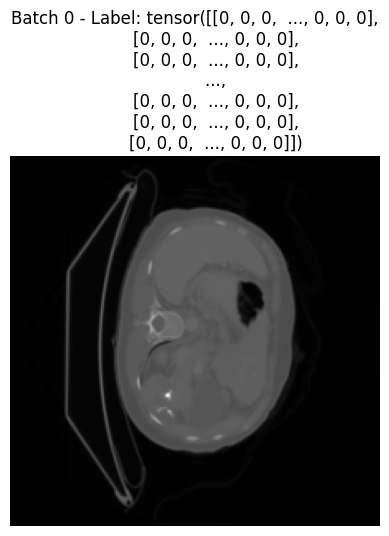

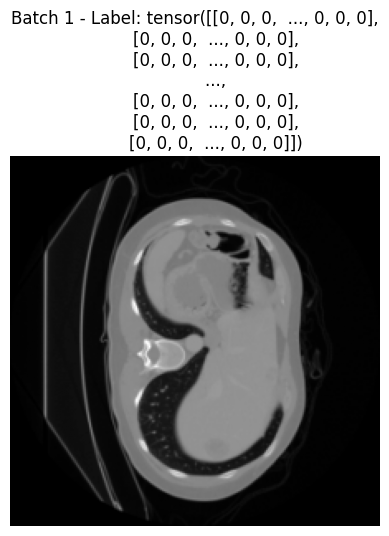

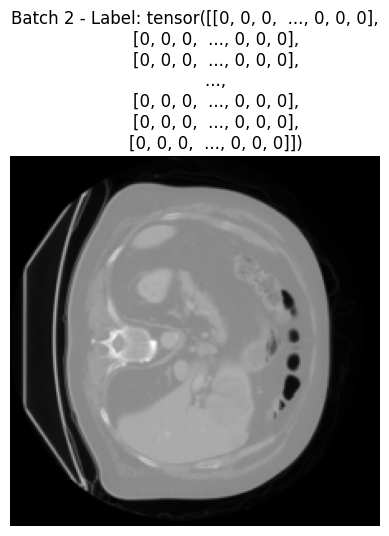

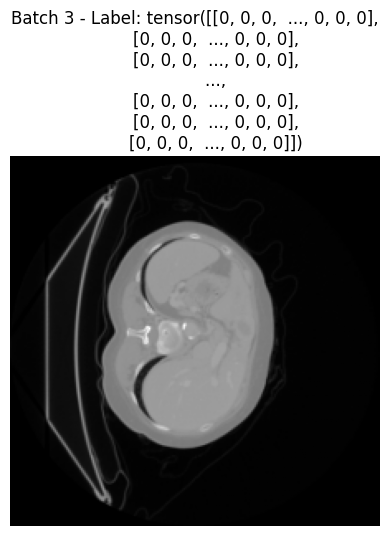

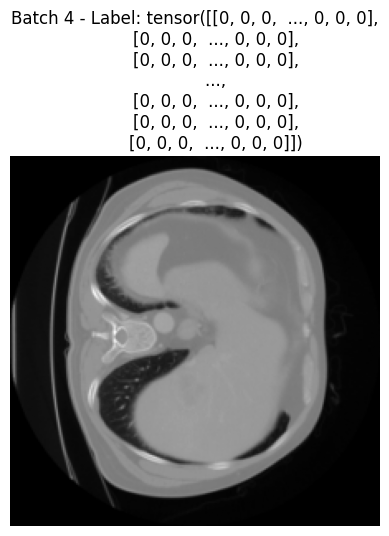

In [31]:
import matplotlib.pyplot as plt

for i, batch in enumerate(train_loader):
    images = batch['image']
    labels = batch['label']

    img = images[0]  # First image in the batch
    label = labels[0]

    # Convert from (C, H, W) to (H, W, C) for matplotlib
    if img.shape[0] == 1:  # grayscale
        img = img.squeeze(0)
        plt.imshow(img.numpy(), cmap='gray')
    else:
        img = img.permute(1, 2, 0)
        plt.imshow(img.numpy())

    plt.title(f"Batch {i} - Label: {label}")
    plt.axis('off')
    plt.show()

    if i == 4:
        break

In [32]:

'''


for epoch in range(args.max_epochs):
    model.train()
    epoch_ce = 0
    epoch_dice = 0
    epoch_accuracy = 0
    epoch_iou = 0

    start_time = time.time()


    for i, batch in tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch}"):
        print(i)
        images = batch['image'].cuda()
        print(batch['image'])
        labels = batch['label'].cuda()

        outputs = model(images)
        loss_ce = ce_loss(outputs, labels)
        loss_dice = dice_loss(outputs, labels, softmax=True)
        loss = 0.4 * loss_ce + 0.6 * loss_dice

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        iter_num += 1
        lr_ = args.base_lr * (1.0 - iter_num / max_iterations) ** 0.9
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr_

        epoch_ce += loss_ce.item()
        epoch_dice += loss_dice.item()

        preds = torch.argmax(outputs, dim=1)
        correct = (preds == labels).float().mean().item()
        epoch_accuracy += correct
        epoch_iou += compute_iou(preds, labels, args.num_classes)

    # Averages for the epoch
    epoch_ce /= len(train_loader)
    epoch_dice /= len(train_loader)
    epoch_accuracy /= len(train_loader)
    epoch_iou /= len(train_loader)
    total_loss = 0.4 * epoch_ce + 0.6 * epoch_dice

    epoch_losses.append(total_loss)
    epoch_accuracies.append(epoch_accuracy)
    epoch_dice_scores.append(1 - epoch_dice)  # Dice Score = 1 - Dice Loss
    epoch_ious.append(epoch_iou)

    end_time = time.time()
    print(f"Epoch {epoch} took {(end_time - start_time)/60:.2f} minutes")
    print(f" → Train Loss: {total_loss:.4f} | CE: {epoch_ce:.4f} | Dice Loss: {epoch_dice:.4f}")
    print(f" → Train Accuracy: {epoch_accuracy:.4f} | Train IoU: {epoch_iou:.4f}")

    # --- Validation Phase ---
    model.eval()
    val_loss = 0
    val_correct = 0
    val_iou = 0
    val_dice = 0

    with torch.no_grad():
        for batch in val_loader:
            images = batch['image'].cuda()
            labels = batch['label'].cuda()

            outputs = model(images)
            loss_ce_val = ce_loss(outputs, labels)
            loss_dice_val = dice_loss(outputs, labels)
            loss_val = 0.4 * loss_ce_val + 0.6 * loss_dice_val
            val_loss += loss_val.item()

            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).float().mean().item()
            val_iou += compute_iou(preds, labels, args.num_classes)
            val_dice += 1 - loss_dice_val.item()

    val_loss /= len(val_loader)
    val_acc = val_correct / len(val_loader)
    val_iou /= len(val_loader)
    val_dice /= len(val_loader)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    val_ious.append(val_iou)
    val_dice_scores.append(val_dice)

    print(f" → Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f} | Val IoU: {val_iou:.4f} | Val Dice: {val_dice:.4f}")

    # --- Early Stopping Logic ---
    if total_loss < best_loss:
        torch.save(model.state_dict(), os.path.join(args.snapshot_path, 'best_model.pth'))
        best_loss = total_loss
        trigger_times = 0
    else:
        torch.save(model.state_dict(), os.path.join(args.snapshot_path, 'last_model.pth'))
        trigger_times += 1
        print(f"EarlyStopping counter: {trigger_times} out of {patience}")
        if trigger_times >= patience:
            print("Early stopping triggered. Stopping training.")
            break

# === Plotting Accuracy and Loss ===
epochs = range(1, len(epoch_losses) + 1)
plt.figure(figsize=(14, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs, epoch_accuracies, label='Train Accuracy', marker='o')
plt.plot(epochs, val_accuracies, label='Val Accuracy', marker='x')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, epoch_losses, label='Train Loss', marker='o')
plt.plot(epochs, val_losses, label='Val Loss', marker='x')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show() '''


'\n\n\nfor epoch in range(args.max_epochs):\n    model.train()\n    epoch_ce = 0\n    epoch_dice = 0\n    epoch_accuracy = 0\n    epoch_iou = 0\n\n    start_time = time.time()\n\n\n    for i, batch in tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch}"):\n        print(i)\n        images = batch[\'image\'].cuda()\n        print(batch[\'image\'])\n        labels = batch[\'label\'].cuda()\n\n        outputs = model(images)\n        loss_ce = ce_loss(outputs, labels)\n        loss_dice = dice_loss(outputs, labels, softmax=True)\n        loss = 0.4 * loss_ce + 0.6 * loss_dice\n\n        optimizer.zero_grad()\n        loss.backward()\n        optimizer.step()\n\n        iter_num += 1\n        lr_ = args.base_lr * (1.0 - iter_num / max_iterations) ** 0.9\n        for param_group in optimizer.param_groups:\n            param_group[\'lr\'] = lr_\n\n        epoch_ce += loss_ce.item()\n        epoch_dice += loss_dice.item()\n\n        preds = torch.argmax(outputs, dim=1)

Epoch 0: 100%|██████████| 883/883 [02:40<00:00,  5.50it/s]



Epoch 0 took 2.68 minutes
 → Train Loss: 0.4127 | CE: 0.0611 | Dice Loss: 0.6470
 → Train Accuracy: 0.9834 | Train IoU: 0.5024
 → Val Loss: 0.3948 | Val Accuracy: 0.9876 | Val IoU: 0.4938 | Val Dice: 0.3716


Epoch 1: 100%|██████████| 883/883 [02:37<00:00,  5.61it/s]



Epoch 1 took 2.62 minutes
 → Train Loss: 0.3929 | CE: 0.0525 | Dice Loss: 0.6197
 → Train Accuracy: 0.9783 | Train IoU: 0.5335
 → Val Loss: 0.3863 | Val Accuracy: 0.9831 | Val IoU: 0.5403 | Val Dice: 0.3884


Epoch 2: 100%|██████████| 883/883 [02:37<00:00,  5.60it/s]


...

Epoch 96: 100%|██████████| 883/883 [02:36<00:00,  5.66it/s]



Epoch 96 took 2.60 minutes
 → Train Loss: 0.2165 | CE: 0.0047 | Dice Loss: 0.3576
 → Train Accuracy: 0.9990 | Train IoU: 0.9372
 → Val Loss: 0.2293 | Val Accuracy: 0.9979 | Val IoU: 0.8972 | Val Dice: 0.6261


Epoch 97: 100%|██████████| 883/883 [02:34<00:00,  5.71it/s]



Epoch 97 took 2.58 minutes
 → Train Loss: 0.2163 | CE: 0.0047 | Dice Loss: 0.3573
 → Train Accuracy: 0.9990 | Train IoU: 0.9369
 → Val Loss: 0.2283 | Val Accuracy: 0.9979 | Val IoU: 0.8998 | Val Dice: 0.6274


Epoch 98:   0%|          | 0/883 [00:00<?, ?it/s]

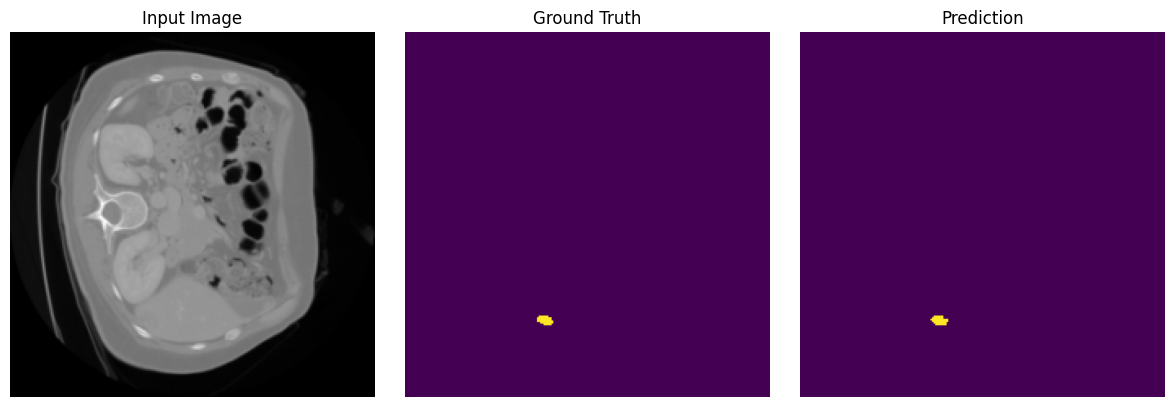

Epoch 98:   0%|          | 1/883 [00:00<08:28,  1.73it/s]

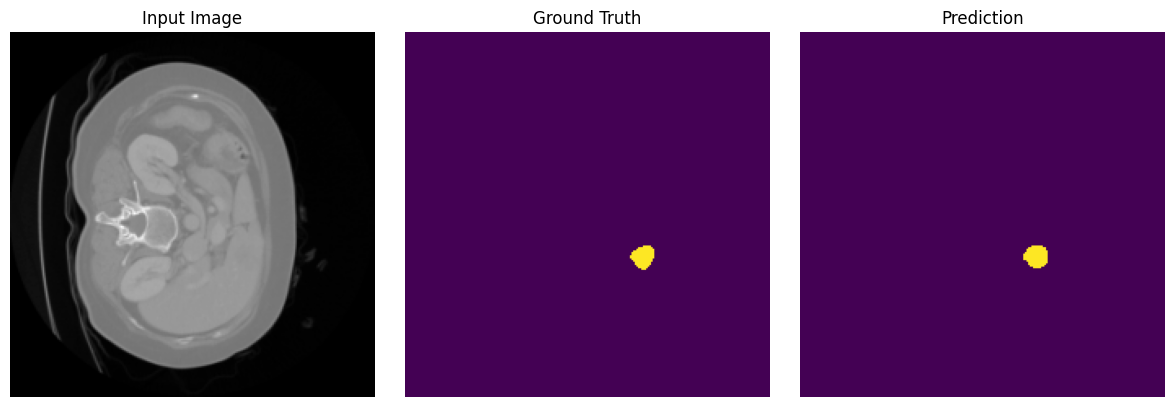

Epoch 98:   0%|          | 2/883 [00:01<07:10,  2.05it/s]

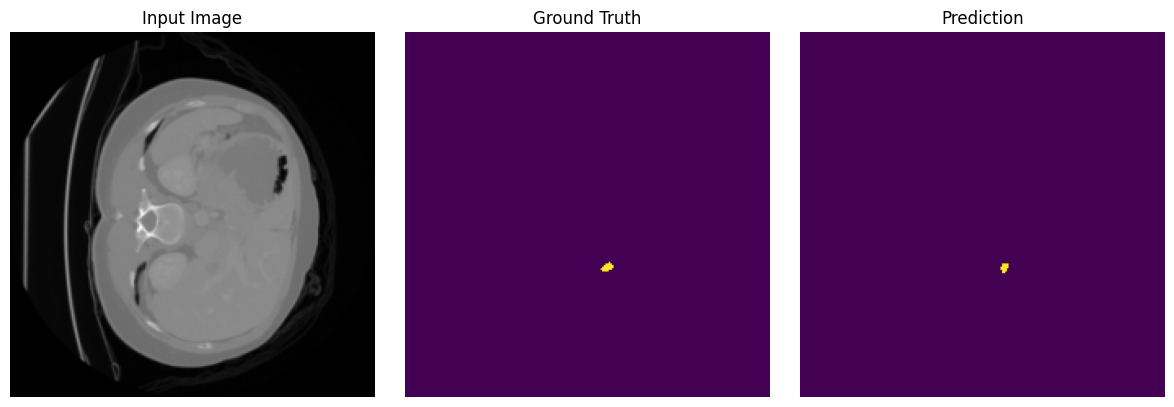

Epoch 98:   0%|          | 3/883 [00:01<06:31,  2.25it/s]

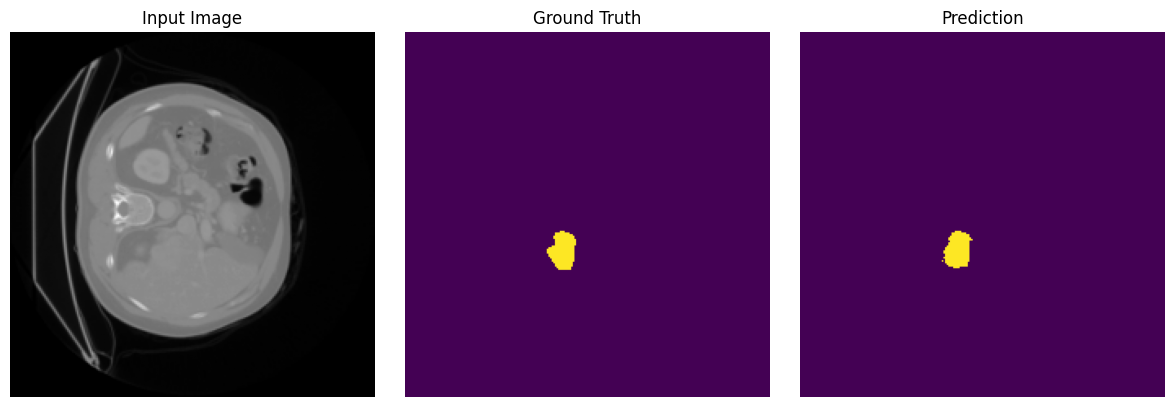

Epoch 98:   0%|          | 4/883 [00:01<06:10,  2.37it/s]

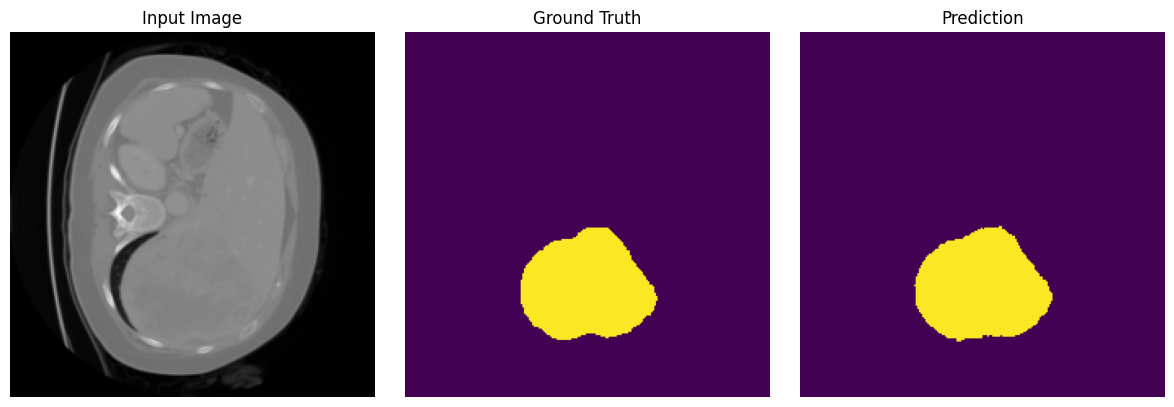

Epoch 98:   1%|          | 5/883 [00:02<06:01,  2.43it/s]

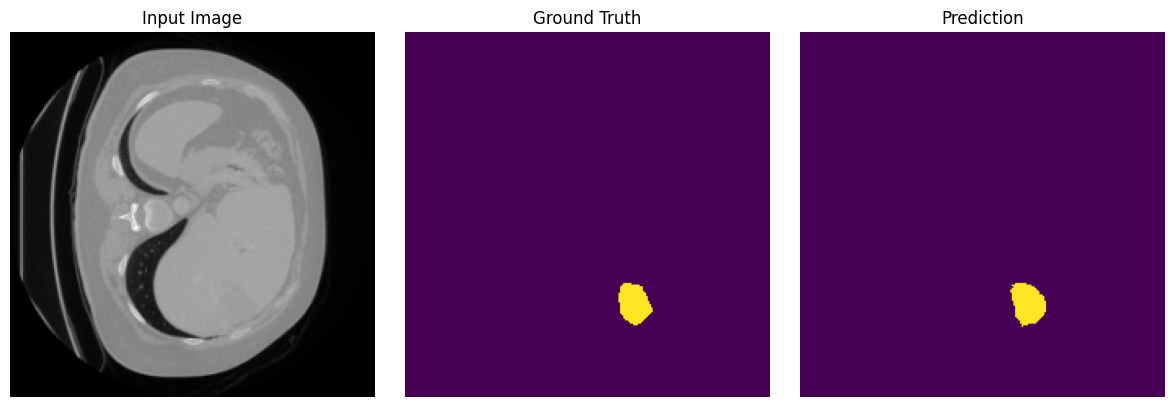

Epoch 98:   1%|          | 6/883 [00:03<10:57,  1.33it/s]

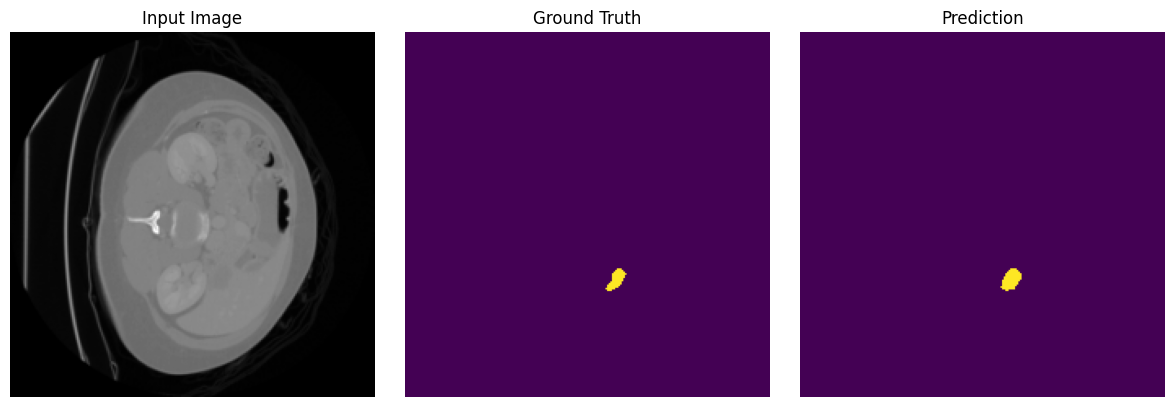

Epoch 98:   1%|          | 7/883 [00:03<09:18,  1.57it/s]

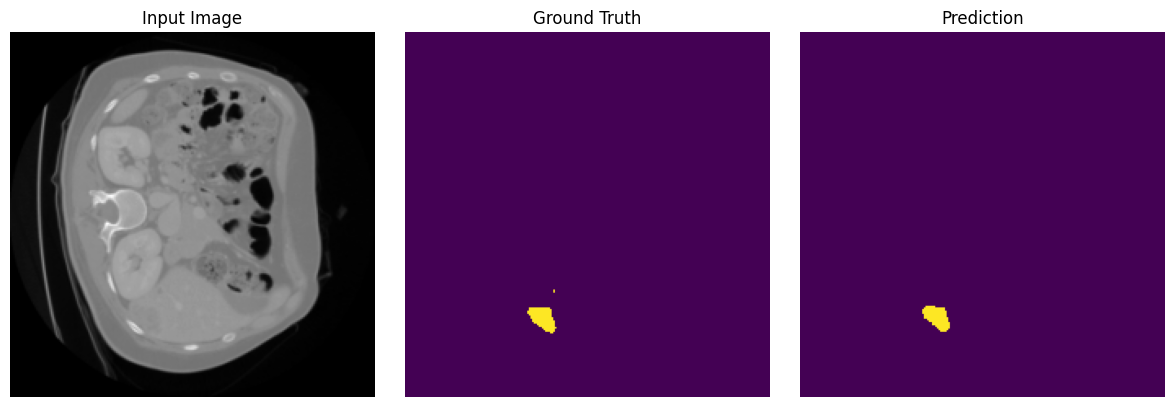

Epoch 98:   1%|          | 8/883 [00:04<08:11,  1.78it/s]

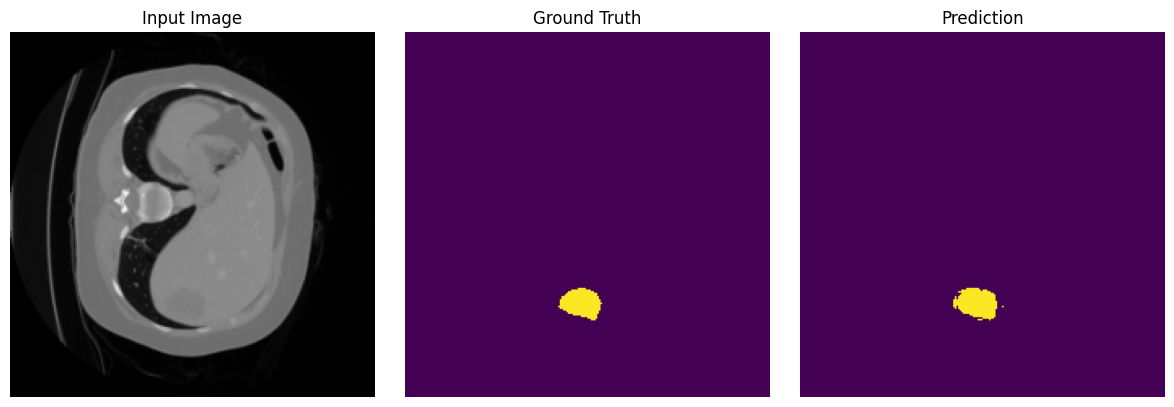

Epoch 98:   1%|          | 9/883 [00:04<07:23,  1.97it/s]

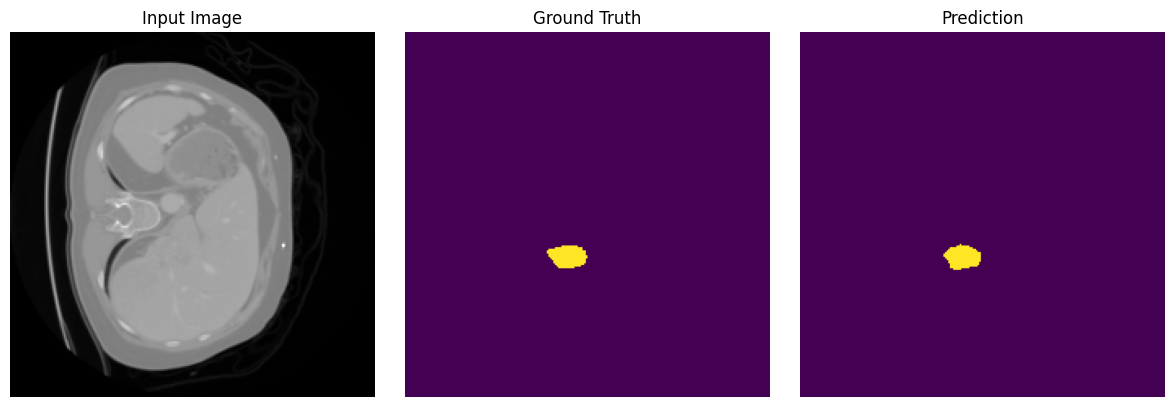

Epoch 98: 100%|██████████| 883/883 [02:37<00:00,  5.61it/s]



Epoch 98 took 2.62 minutes
 → Train Loss: 0.2166 | CE: 0.0047 | Dice Loss: 0.3578
 → Train Accuracy: 0.9990 | Train IoU: 0.9371
 → Val Loss: 0.2285 | Val Accuracy: 0.9979 | Val IoU: 0.8994 | Val Dice: 0.6271
EarlyStopping counter: 1 out of 10


Epoch 99: 100%|██████████| 883/883 [02:35<00:00,  5.69it/s]



Epoch 99 took 2.59 minutes
 → Train Loss: 0.2161 | CE: 0.0047 | Dice Loss: 0.3570
 → Train Accuracy: 0.9990 | Train IoU: 0.9378
 → Val Loss: 0.2284 | Val Accuracy: 0.9979 | Val IoU: 0.8999 | Val Dice: 0.6274


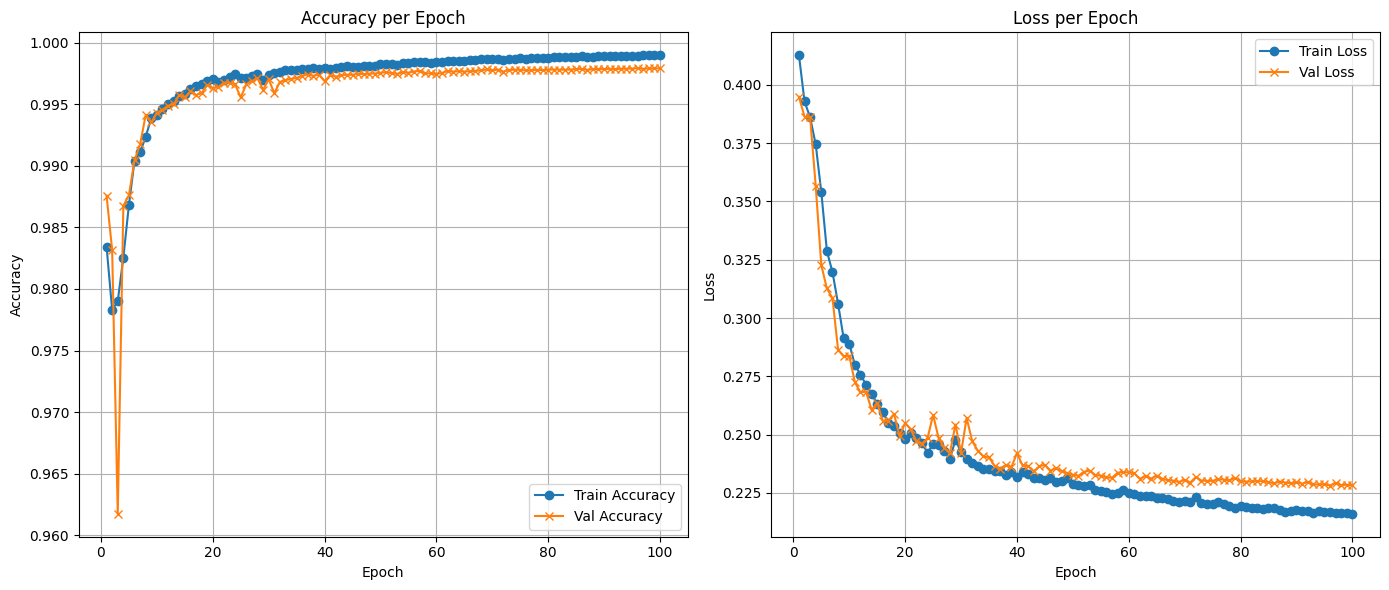

In [33]:
import os
import time
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

# Create tracking lists
epoch_losses = []
epoch_accuracies = []
epoch_dice_scores = []
epoch_ious = []
val_losses = []
val_accuracies = []
val_dice_scores = []
val_ious = []

# --- Training Setup ---
max_iterations = args.max_epochs * len(train_loader)
best_loss = float("inf")
iter_num = 0
trigger_times = 0
patience = 10  # or args.patience if available

# --- Training Loop ---
for epoch in range(args.max_epochs):
    model.train()
    epoch_ce = 0
    epoch_dice = 0
    epoch_accuracy = 0
    epoch_iou = 0
    start_time = time.time()

    # Training
    for i, batch in tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch}"):
        images = batch['image'].cuda()
        labels = batch['label'].cuda()

        outputs = model(images)
        # print(outputs)
        loss_ce = ce_loss(outputs, labels)
        loss_dice = dice_loss(outputs, labels, softmax=True)
        loss = 0.4 * loss_ce + 0.6 * loss_dice

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        iter_num += 1
        lr_ = args.base_lr * (1.0 - iter_num / max_iterations) ** 0.9
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr_

        epoch_ce += loss_ce.item()
        epoch_dice += loss_dice.item()

        preds = torch.argmax(outputs, dim=1)
        correct = (preds == labels).float().mean().item()
        epoch_accuracy += correct
        epoch_iou += compute_iou(preds, labels, args.num_classes)

        # Visualize first few batches (optional)
        if epoch == 98 and i < 10:  # visualize first 2 batches of first epoch
            img = images[0].detach().cpu()
            lbl = labels[0].detach().cpu()
            pred = preds[0].detach().cpu()

            plt.figure(figsize=(12, 4))
            plt.subplot(1, 3, 1)
            plt.title("Input Image")
            if img.shape[0] == 1:
                plt.imshow(img.squeeze(0), cmap='gray')
            else:
                plt.imshow(img.permute(1, 2, 0))
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.title("Ground Truth")
            plt.imshow(lbl, cmap='viridis')
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.title("Prediction")
            plt.imshow(pred, cmap='viridis')
            plt.axis('off')

            plt.tight_layout()
            plt.show()

    # --- Epoch Averages ---
    epoch_ce /= len(train_loader)
    epoch_dice /= len(train_loader)
    epoch_accuracy /= len(train_loader)
    epoch_iou /= len(train_loader)
    total_loss = 0.4 * epoch_ce + 0.6 * epoch_dice

    epoch_losses.append(total_loss)
    epoch_accuracies.append(epoch_accuracy)
    epoch_dice_scores.append(1 - epoch_dice)
    epoch_ious.append(epoch_iou)

    end_time = time.time()
    print(f"\nEpoch {epoch} took {(end_time - start_time)/60:.2f} minutes")
    print(f" → Train Loss: {total_loss:.4f} | CE: {epoch_ce:.4f} | Dice Loss: {epoch_dice:.4f}")
    print(f" → Train Accuracy: {epoch_accuracy:.4f} | Train IoU: {epoch_iou:.4f}")

    # --- Validation Phase ---
    model.eval()
    val_loss = 0
    val_correct = 0
    val_iou = 0
    val_dice = 0

    with torch.no_grad():
        for batch in val_loader:
            images = batch['image'].cuda()
            labels = batch['label'].cuda()

            outputs = model(images)
            loss_ce_val = ce_loss(outputs, labels)
            loss_dice_val = dice_loss(outputs, labels, softmax=True)
            loss_val = 0.4 * loss_ce_val + 0.6 * loss_dice_val
            val_loss += loss_val.item()

            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).float().mean().item()
            val_iou += compute_iou(preds, labels, args.num_classes)
            val_dice += 1 - loss_dice_val.item()

    val_loss /= len(val_loader)
    val_acc = val_correct / len(val_loader)
    val_iou /= len(val_loader)
    val_dice /= len(val_loader)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    val_ious.append(val_iou)
    val_dice_scores.append(val_dice)

    print(f" → Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f} | Val IoU: {val_iou:.4f} | Val Dice: {val_dice:.4f}")

    # --- Early Stopping ---
    if total_loss < best_loss:
        torch.save(model.state_dict(), os.path.join(args.snapshot_path, 'best_model.pth'))
        best_loss = total_loss
        trigger_times = 0
    else:
        torch.save(model.state_dict(), os.path.join(args.snapshot_path, 'last_model.pth'))
        trigger_times += 1
        print(f"EarlyStopping counter: {trigger_times} out of {patience}")
        if trigger_times >= patience:
            print("✅ Early stopping triggered. Training stopped.")
            break

# --- Final Plots ---
epochs = range(1, len(epoch_losses) + 1)
plt.figure(figsize=(14, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs, epoch_accuracies, label='Train Accuracy', marker='o')
plt.plot(epochs, val_accuracies, label='Val Accuracy', marker='x')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs, epoch_losses, label='Train Loss', marker='o')
plt.plot(epochs, val_losses, label='Val Loss', marker='x')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
